# 📊 Análisis Exploratorio de Datos (EDA) - Lead Scoring

**Objetivo**: Exploración integral del dataset de entrenamiento post-limpieza
- **Dataset**: `02_train_tablon_calidad.pkl`
- **Registros**: 6,279 (post-limpieza)
- **Target**: `compra` (conversión ~37%)

## 🔧 Importaciones y Configuración

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

# Crear carpeta de resultados si no existe
print('✅ Librerías importadas correctamente')


✅ Librerías importadas correctamente


## 📍 PASO INICIAL: Carga del Dataframe y Tipificación de Variables

In [46]:
# Cargar dataframe desde ruta especificada
df = pd.read_pickle("../02_datos/03_Entrenamiento/02_train_tablon_calidad.pkl")

# ⚠️ ELIMINAR VARIABLES CONOCISTE
# Eliminar todas las variables que comienzan con 'conociste_'
columnas_a_eliminar = [col for col in df.columns if col.startswith('conociste_')]
print(f'Eliminando columnas: {columnas_a_eliminar}')
df = df.drop(columns=columnas_a_eliminar)
print(f'Nuevo shape: {df.shape}')

# ⚠️ AGRUPAR CATEGORÍAS MINORITARIAS EN 'fuente'
# Agrupar todas las categorías con menos del 5% en 'Otros'
if 'fuente' in df.columns:
    # Calcular porcentajes
    pct_fuente = df['fuente'].value_counts(normalize=True) * 100
    categorias_principales = pct_fuente[pct_fuente >= 5].index.tolist()
    
    # Agrupar categorías menores al 5% en 'Otros'
    df['fuente'] = df['fuente'].apply(lambda x: x if x in categorias_principales else 'Otros')
    
    print('✓ Variable fuente agrupada')
    print(f'Categorías principales (>=5%): {categorias_principales}')
    print(f'\nDistribución actualizada:')
    print(df['fuente'].value_counts())
    print(f'\nPorcentajes:')
    print(df['fuente'].value_counts(normalize=True) * 100)

print("=" * 80)
print("PASO INICIAL: CARGA DEL TABLÓN Y TIPIFICACIÓN DE VARIABLES")
print("=" * 80)

# Información general
print(f"\n📊 SHAPE del dataframe: {df.shape}")
print(f"   Registros: {df.shape[0]} | Columnas: {df.shape[1]}")

# Primeras filas
print(f"\n📋 PRIMERAS FILAS:")
print(df.head())

# Info detallada
print(f"\n📄 INFORMACIÓN DETALLADA (df.info()):")
df.info()


Eliminando columnas: ['conociste_google', 'conociste_periodico', 'conociste_facebook', 'conociste_referencias']
Nuevo shape: (6279, 17)
✓ Variable fuente agrupada
Categorías principales (>=5%): ['Google', 'Direct Traffic', 'Chat', 'Organic Search']

Distribución actualizada:
fuente
Google            2006
Direct Traffic    1784
Chat              1219
Organic Search     809
Otros              461
Name: count, dtype: int64

Porcentajes:
fuente
Google            31.947762
Direct Traffic    28.412168
Chat              19.413919
Organic Search    12.884217
Otros              7.341933
Name: proportion, dtype: float64
PASO INICIAL: CARGA DEL TABLÓN Y TIPIFICACIÓN DE VARIABLES

📊 SHAPE del dataframe: (6279, 17)
   Registros: 6279 | Columnas: 17

📋 PRIMERAS FILAS:
          id                   origen          fuente no_enviar_email  compra  \
1242  646181                      API          Google              No       0   
8583  582361  Landing Page Submission  Direct Traffic              No    

In [47]:
# ⚠️ AGRUPAR CATEGORÍAS MINORITARIAS EN 'ult_actividad'
# Agrupar todas las categorías con menos del 3% en 'Otros'
if 'ult_actividad' in df.columns:
    # Calcular porcentajes
    pct_ult_actividad = df['ult_actividad'].value_counts(normalize=True) * 100
    categorias_principales = pct_ult_actividad[pct_ult_actividad >= 3].index.tolist()
    
    # Agrupar categorías menores al 3% en 'Otros'
    df['ult_actividad'] = df['ult_actividad'].apply(lambda x: x if x in categorias_principales else 'Otros')
    
    print('✓ Variable ult_actividad agrupada')
    print(f'Categorías principales (>=3%): {categorias_principales}')
    print(f'\nDistribución actualizada:')
    print(df['ult_actividad'].value_counts())
    print(f'\nPorcentajes:')
    print(df['ult_actividad'].value_counts(normalize=True) * 100)

✓ Variable ult_actividad agrupada
Categorías principales (>=3%): ['Email Opened', 'SMS Sent', 'Chat Conversation', 'Page Visited on Website', 'Converted to Lead', 'Email Bounced']

Distribución actualizada:
ult_actividad
Email Opened               2360
SMS Sent                   1876
Chat Conversation           669
Page Visited on Website     459
Otros                       394
Converted to Lead           314
Email Bounced               207
Name: count, dtype: int64

Porcentajes:
ult_actividad
Email Opened               37.585603
SMS Sent                   29.877369
Chat Conversation          10.654563
Page Visited on Website     7.310081
Otros                       6.274885
Converted to Lead           5.000796
Email Bounced               3.296703
Name: proportion, dtype: float64


In [48]:
df.shape

(6279, 17)

In [49]:
print("\n" + "=" * 80)
print("TIPIFICACIÓN DE VARIABLES")
print("=" * 80)

# Análisis de cardinales
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

# Calcular heurística para alta cardinalidad
umbral_alta_cardinalidad = min(50, int(0.1 * df.shape[0]))

print(
    f"\n🔍 UMBRAL ALTA CARDINALIDAD (heurística): {umbral_alta_cardinalidad} categorías")

# Clasificación de numéricas
numeric_discrete = []
numeric_continuous = []

for col in numeric_cols:
    n_unique = df[col].nunique()
    n_rows = df.shape[0]
    discrete_threshold = min(20, int(0.05 * n_rows))

    if n_unique <= discrete_threshold and col != 'id':
        numeric_discrete.append(col)
    else:
        numeric_continuous.append(col)

# Clasificación de categóricas
categorical = []
boolean_cols = []
high_cardinality = []
text_cols = []

for col in object_cols:
    n_unique = df[col].nunique()

    # Detectar booleanas
    unique_vals = df[col].unique()
    if n_unique == 2 and set(str(v).lower() for v in unique_vals).issubset(
            {'yes', 'no', '0', '1', 'true', 'false'}):
        boolean_cols.append(col)
    # Detectar alta cardinalidad
    elif n_unique > umbral_alta_cardinalidad:
        high_cardinality.append(col)
    # Detectar texto
    elif n_unique > min(100, 0.05 * df.shape[0]):
        text_cols.append(col)
    else:
        categorical.append(col)

# Mostrar clasificación
print("\n" + "-" * 80)
print("CLASIFICACIÓN DE VARIABLES:")
print("-" * 80)

print(f"\n✔️  NUMÉRICAS DISCRETAS ({len(numeric_discrete)}):")
for col in numeric_discrete:
    print(f"   - {col}: {df[col].nunique()} valores únicos")

print(f"\n✔️  NUMÉRICAS CONTINUAS ({len(numeric_continuous)}):")
for col in numeric_continuous:
    print(f"   - {col}: {df[col].nunique()} valores únicos")

print(f"\n✔️  CATEGÓRICAS ({len(categorical)}):")
for col in categorical:
    print(f"   - {col}: {df[col].nunique()} categorías")

print(f"\n✔️  BOOLEANAS ({len(boolean_cols)}):")
for col in boolean_cols:
    print(f"   - {col}: {df[col].nunique()} valores")

print(f"\n✔️  ALTA CARDINALIDAD ({len(high_cardinality)}):")
for col in high_cardinality:
    print(f"   - {col}: {df[col].nunique()} categorías")

print(f"\n✔️  TEXTO ({len(text_cols)}):")
for col in text_cols:
    print(f"   - {col}: {df[col].nunique()} valores únicos")

print(f"\n✔️  FECHAS ({len(datetime_cols)}):")
for col in datetime_cols:
    print(f"   - {col}")



TIPIFICACIÓN DE VARIABLES

🔍 UMBRAL ALTA CARDINALIDAD (heurística): 50 categorías

--------------------------------------------------------------------------------
CLASIFICACIÓN DE VARIABLES:
--------------------------------------------------------------------------------

✔️  NUMÉRICAS DISCRETAS (6):
   - compra: 2 valores únicos
   - score_actividad: 13 valores únicos
   - score_perfil: 11 valores únicos
   - tiene_score_actividad: 2 valores únicos
   - tiene_score_perfil: 2 valores únicos
   - usuario_nuevo: 2 valores únicos

✔️  NUMÉRICAS CONTINUAS (4):
   - id: 6279 valores únicos
   - visitas_total: 40 valores únicos
   - tiempo_en_site_total: 1555 valores únicos
   - paginas_vistas_visita: 98 valores únicos

✔️  CATEGÓRICAS (5):
   - origen: 4 categorías
   - fuente: 5 categorías
   - ult_actividad: 7 categorías
   - ambito: 20 categorías
   - ocupacion: 7 categorías

✔️  BOOLEANAS (2):
   - no_enviar_email: 2 valores
   - descarga_lm: 2 valores

✔️  ALTA CARDINALIDAD (0):

✔️ 

In [50]:
# Alertas preliminares
import json
print("\n" + "=" * 80)
print("ALERTAS PRELIMINARES AUTOMÁTICAS")
print("=" * 80)

# Columnas constantes
const_cols = [col for col in df.columns if df[col].nunique() == 1]
if const_cols:
    print(f"\n⚠️  COLUMNAS CONSTANTES (sin varianza):")
    for col in const_cols:
        print(f"   - {col}: {df[col].unique()[0]}")

# Columnas con alto % de missing
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    print(f"\n⚠️  COLUMNAS CON MISSING VALUES:")
    for col, pct in missing_pct.items():
        print(f"   - {col}: {pct:.2f}% nulos")
else:
    print(f"\n✅ No hay valores faltantes (como se esperaba post-limpieza)")

# Cardinalidad excesiva
high_card_alert = [
    col for col in categorical +
    boolean_cols if df[col].nunique() > 50]
if high_card_alert:
    print(f"\n⚠️  VARIABLES CON CARDINALIDAD POTENCIALMENTE EXCESIVA:")
    for col in high_card_alert:
        print(f"   - {col}: {df[col].nunique()} categorías")

# Resumen
print("\n" + "=" * 80)
print("RESUMEN INICIAL")
print("=" * 80)
print(f"""
📊 Total de variables: {df.shape[1]}
   • Numéricas discretas: {len(numeric_discrete)}
   • Numéricas continuas: {len(numeric_continuous)}
   • Categóricas: {len(categorical)}
   • Booleanas: {len(boolean_cols)}
   • Alta cardinalidad: {len(high_cardinality)}
   • Texto: {len(text_cols)}
   • Fechas: {len(datetime_cols)}

✅ Estado de nulos: {df.isnull().sum().sum()} nulos totales
🎯 Target variable: compra (conversión ~37%)
🔑 ID variable: id ({df['id'].nunique()} valores únicos = sin duplicados)
""")

# Guardar clasificación para referencia posterior
clasificacion = {
    'numeric_discrete': numeric_discrete,
    'numeric_continuous': numeric_continuous,
    'categorical': categorical,
    'boolean': boolean_cols,
    'high_cardinality': high_cardinality,
    'text': text_cols,
    'datetime': datetime_cols
}

with open('06_resultados/clasificacion_variables.json', 'w', encoding='utf-8') as f:
    json.dump(clasificacion, f, ensure_ascii=False, indent=2)

print("✅ Clasificación guardada en: 06_resultados/clasificacion_variables.json")



ALERTAS PRELIMINARES AUTOMÁTICAS

✅ No hay valores faltantes (como se esperaba post-limpieza)

RESUMEN INICIAL

📊 Total de variables: 17
   • Numéricas discretas: 6
   • Numéricas continuas: 4
   • Categóricas: 5
   • Booleanas: 2
   • Alta cardinalidad: 0
   • Texto: 0
   • Fechas: 0

✅ Estado de nulos: 0 nulos totales
🎯 Target variable: compra (conversión ~37%)
🔑 ID variable: id (6279 valores únicos = sin duplicados)

✅ Clasificación guardada en: 06_resultados/clasificacion_variables.json


## 📈 TAREA 2: Análisis Estadístico de Variables Numéricas

### Parte 1: Variables Numéricas Discretas

In [51]:
print("\n" + "=" * 100)
print("TAREA 2: EDA NUMÉRICAS (ANÁLISIS ESTADÍSTICO)")
print("=" * 100)

print("\n" + "=" * 100)
print("PARTE 1: VARIABLES NUMÉRICAS DISCRETAS")
print("=" * 100)

for col in numeric_discrete:
    print(f"\n{'─' * 100}")
    print(f"Variable: {col}")
    print(f"{'─' * 100}")

    # Descripción básica
    data = df[col]
    print(f"Tipo de dato: {data.dtype} | Valores únicos: {data.nunique()}")
    print(f"Valores: {sorted(data.unique())}")

    # Estadísticas extendidas
    print(f"\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
    stats_df = pd.DataFrame(
        {
            'Métrica': [
                'Min',
                'Q1 (25%)',
                'Q5 (5%)',
                'Mediana (50%)',
                'Q95 (95%)',
                'Q99 (99%)',
                'Max',
                'Media',
                'Desv. Est.',
                'Skewness',
                'Kurtosis'],
            'Valor': [
                data.min(),
                data.quantile(0.25),
                data.quantile(0.05),
                data.quantile(0.50),
                data.quantile(0.95),
                data.quantile(0.99),
                data.max(),
                data.mean(),
                data.std(),
                data.skew(),
                data.kurtosis()]})
    print(stats_df.to_string(index=False))

    # Frecuencias y missing
    print(f"\n📋 FRECUENCIAS Y MISSING:")
    freq_table = data.value_counts().sort_index()
    freq_df = pd.DataFrame({
        'Valor': freq_table.index,
        'Frecuencia': freq_table.values,
        '%': (freq_table.values / len(df) * 100).round(2)
    })
    print(freq_df.to_string(index=False))

    missing_count = data.isnull().sum()
    missing_pct = missing_count / len(df) * 100
    print(f"Missing: {missing_count} ({missing_pct:.2f}%)")

    # Detección de outliers con IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"\n⚠️  OUTLIERS (método IQR):")
    print(f"Rango IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outliers detectados: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}%)")
    if len(outliers) > 0:
        print(f"Valores: {sorted(outliers.unique())}")


TAREA 2: EDA NUMÉRICAS (ANÁLISIS ESTADÍSTICO)

PARTE 1: VARIABLES NUMÉRICAS DISCRETAS

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: compra
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: int64 | Valores únicos: 2
Valores: [np.int64(0), np.int64(1)]

📊 ESTADÍSTICAS DESCRIPTIVAS:
      Métrica     Valor
          Min  0.000000
     Q1 (25%)  0.000000
      Q5 (5%)  0.000000
Mediana (50%)  0.000000
    Q95 (95%)  1.000000
    Q99 (99%)  1.000000
          Max  1.000000
        Media  0.371875
   Desv. Est.  0.483344
     Skewness  0.530332
     Kurtosis -1.719296

📋 FRECUENCIAS Y MISSING:
 Valor  Frecuencia     %
     0        3944 62.81
     1        2335 37.19
Missing: 0 (0.00%)

⚠️  OUTLIERS (método IQR):
Rango IQR: [-1.50, 2.50]
Outliers detectados: 0 (0.00%)

──────────────────────────────────────────────────────────────────────────────────────────────


⚠️  OUTLIERS (método IQR):
Rango IQR: [-1.50, 2.50]
Outliers detectados: 0 (0.00%)

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: tiene_score_perfil
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: int64 | Valores únicos: 2
Valores: [np.int64(0), np.int64(1)]

📊 ESTADÍSTICAS DESCRIPTIVAS:
      Métrica     Valor
          Min  0.000000
     Q1 (25%)  0.000000
      Q5 (5%)  0.000000
Mediana (50%)  1.000000
    Q95 (95%)  1.000000
    Q99 (99%)  1.000000
          Max  1.000000
        Media  0.542602
   Desv. Est.  0.498221
     Skewness -0.171072
     Kurtosis -1.971362

📋 FRECUENCIAS Y MISSING:
 Valor  Frecuencia     %
     0        2872 45.74
     1        3407 54.26
Missing: 0 (0.00%)

⚠️  OUTLIERS (método IQR):
Rango IQR: [-1.50, 2.50]
Outliers detectados: 0 (0.00%)

─────────────────────────────────────────────────────────────────────────────────────

### Parte 2: Variables Numéricas Continuas

In [52]:
import pandas as pd

# Asegúrate de tener df y numeric_continuous definidos
# df = pd.read_csv('tu_archivo.csv')
# numeric_continuous = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("\n\n" + "=" * 100)
print("PARTE 2: VARIABLES NUMÉRICAS CONTINUAS")
print("=" * 100)

for col in numeric_continuous:
    print(f"\n{'─' * 100}")
    print(f"Variable: {col}")
    print(f"{'─' * 100}")

    # Descripción básica
    data = df[col].dropna()  # Eliminar nulos para cálculos
    print(f"Tipo de dato: {df[col].dtype} | Valores únicos: {df[col].nunique()}")

    if len(data) == 0:
        print("⚠️ No hay datos válidos para esta variable")
        continue

    # Estadísticas extendidas
    print(f"\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
    stats_df = pd.DataFrame({
        'Métrica': ['Min', 'Q1 (25%)', 'P1 (1%)', 'P5 (5%)', 'Mediana (50%)', 
                    'P95 (95%)', 'P99 (99%)', 'Max', 'Media', 'Desv. Est.', 
                    'Skewness', 'Kurtosis'],
        'Valor': [
            data.min(), data.quantile(0.25), data.quantile(0.01),
            data.quantile(0.05), data.quantile(0.50), data.quantile(0.95),
            data.quantile(0.99), data.max(), data.mean(), data.std(),
            data.skew(), data.kurtosis()
        ]
    })
    print(stats_df.to_string(index=False, float_format='%.2f'))

    missing_count = df[col].isnull().sum()
    missing_pct = missing_count / len(df) * 100
    print(f"\nMissing: {missing_count} ({missing_pct:.2f}%)")

    # Detección de outliers con IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"\n⚠️ OUTLIERS (método IQR):")
    print(f"Rango IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outliers detectados: {len(outliers)} ({len(outliers) / len(data) * 100:.2f}%)")

    # Distribución
    print(f"\n📈 DISTRIBUCIÓN:")
    print(f"Rango: {data.max() - data.min():.2f}")
    if data.mean() != 0:
        cv = data.std() / data.mean()
        print(f"Coeficiente de variación: {cv:.4f}")
    else:
        print("Coeficiente de variación: N/A (media = 0)")




PARTE 2: VARIABLES NUMÉRICAS CONTINUAS

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: id
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: int64 | Valores únicos: 6279

📊 ESTADÍSTICAS DESCRIPTIVAS:
      Métrica     Valor
          Min 579533.00
     Q1 (25%) 596719.00
      P1 (1%) 580300.14
      P5 (5%) 582735.40
Mediana (50%) 615645.00
    P95 (95%) 655384.10
    P99 (99%) 659608.54
          Max 660737.00
        Media 617273.02
   Desv. Est.  23403.80
     Skewness      0.13
     Kurtosis     -1.21

Missing: 0 (0.00%)

⚠️ OUTLIERS (método IQR):
Rango IQR: [535621.75, 698547.75]
Outliers detectados: 0 (0.00%)

📈 DISTRIBUCIÓN:
Rango: 81204.00
Coeficiente de variación: 0.0379

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: visitas_total
──────────────────────────────────────────────────────

### Parte 3: Matriz de Correlaciones

In [53]:
print("\n\n" + "=" * 100)
print("MATRIZ DE CORRELACIONES (TODAS LAS VARIABLES NUMÉRICAS)")
print("=" * 100)

all_numeric = numeric_discrete + numeric_continuous
corr_matrix = df[all_numeric].corr()

print("\n🔗 CORRELACIONES CON VARIABLE TARGET (compra):")
target_corr = corr_matrix['compra'].sort_values(ascending=False)
print(target_corr)

# Correlaciones altas
print(f"\n⚠️  CORRELACIONES ALTAS (> 0.7 o < -0.7, excluyendo target):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr:
    for col1, col2, corr in sorted(
            high_corr, key=lambda x: abs(
            x[2]), reverse=True):
        print(f"{col1} <-> {col2}: {corr:.3f}")
else:
    print("No se detectaron correlaciones altas (> 0.7)")

print("\n" + "=" * 100)
print("✅ FIN TAREA 2 - ANÁLISIS ESTADÍSTICO")
print("=" * 100)




MATRIZ DE CORRELACIONES (TODAS LAS VARIABLES NUMÉRICAS)

🔗 CORRELACIONES CON VARIABLE TARGET (compra):
compra                   1.000000
tiempo_en_site_total     0.378250
visitas_total            0.036350
id                       0.016805
usuario_nuevo            0.016521
paginas_vistas_visita    0.016201
score_perfil             0.009725
score_actividad          0.000956
tiene_score_perfil      -0.016521
tiene_score_actividad   -0.016521
Name: compra, dtype: float64

⚠️  CORRELACIONES ALTAS (> 0.7 o < -0.7, excluyendo target):
tiene_score_actividad <-> tiene_score_perfil: 1.000
tiene_score_actividad <-> usuario_nuevo: -1.000
tiene_score_perfil <-> usuario_nuevo: -1.000
score_actividad <-> usuario_nuevo: -0.990
score_actividad <-> tiene_score_actividad: 0.990
score_actividad <-> tiene_score_perfil: 0.990
score_perfil <-> tiene_score_actividad: 0.987
score_perfil <-> tiene_score_perfil: 0.987
score_perfil <-> usuario_nuevo: -0.987
score_actividad <-> score_perfil: 0.974

✅ FIN TAREA 2

## 📊 TAREA 3: Análisis Gráfico de Variables Numéricas

### Gráficos: Variables Numéricas Discretas


TAREA 3: EDA NUMÉRICAS (ANÁLISIS GRÁFICO)

GRÁFICOS: VARIABLES NUMÉRICAS DISCRETAS


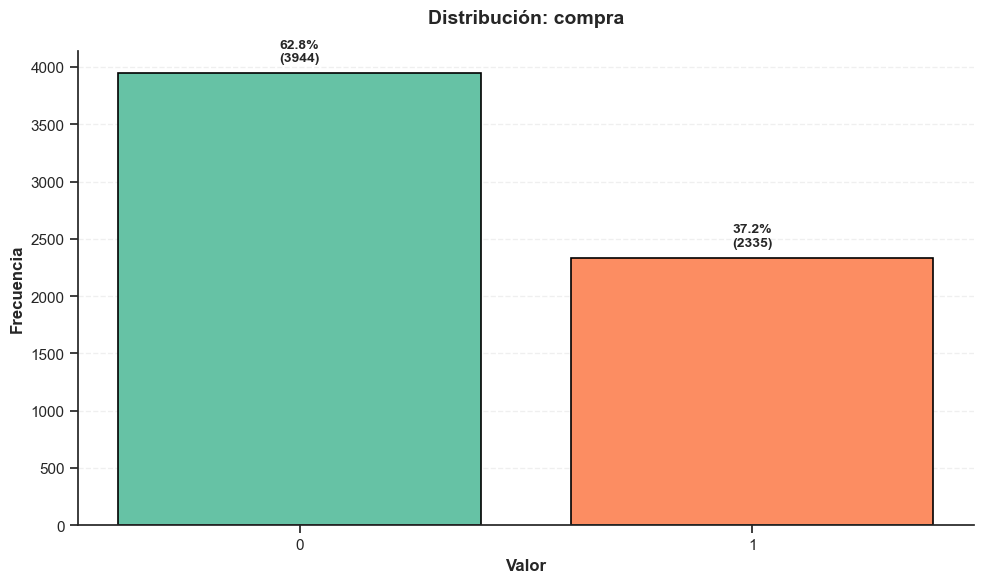

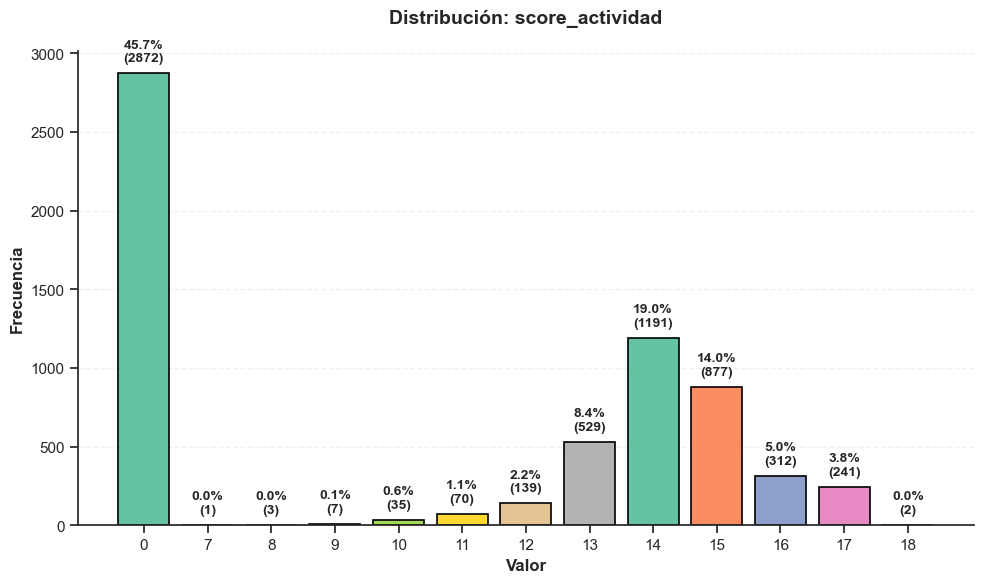

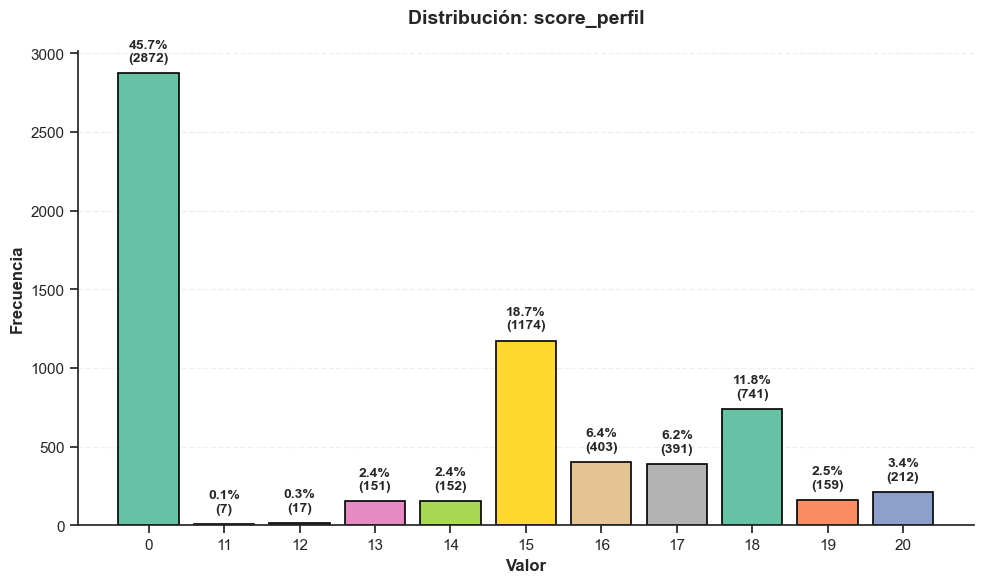

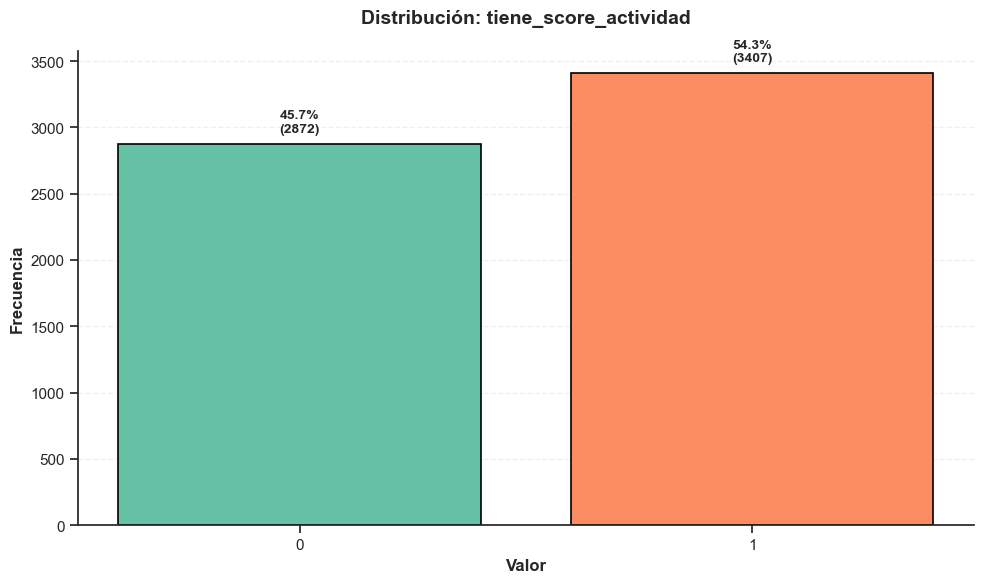

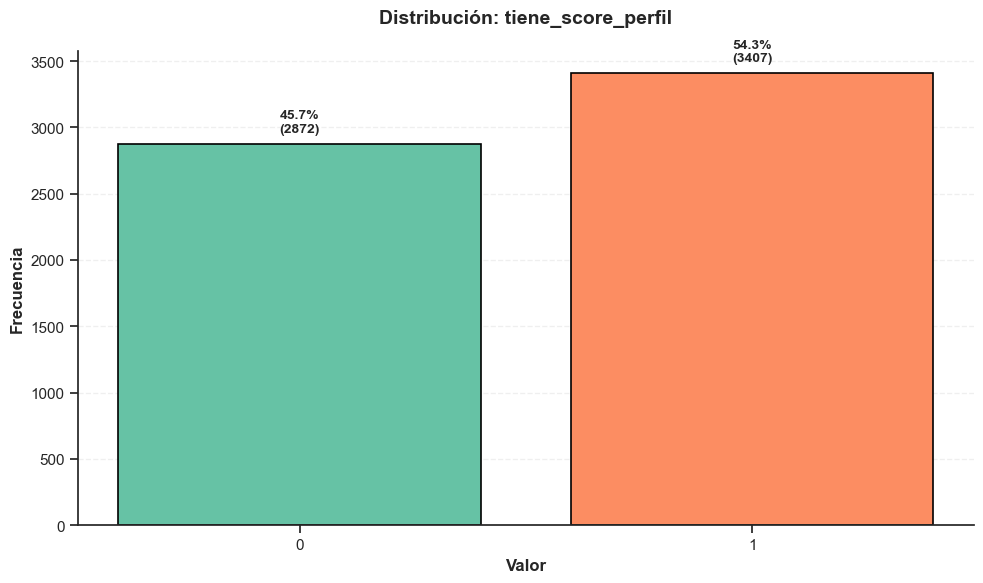

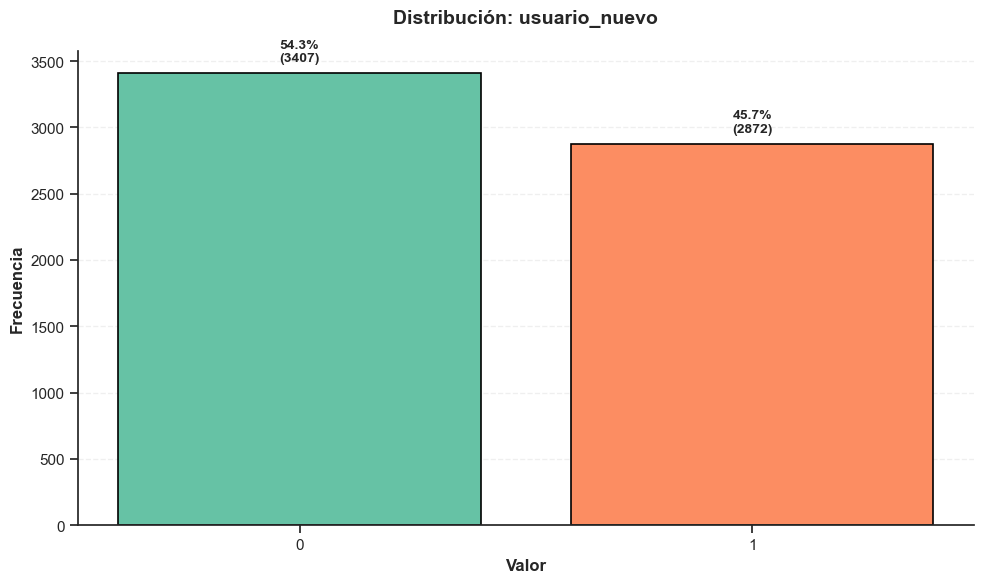

In [54]:
print("\n" + "=" * 100)
print("TAREA 3: EDA NUMÉRICAS (ANÁLISIS GRÁFICO)")
print("=" * 100)

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

print("\n" + "=" * 100)
print("GRÁFICOS: VARIABLES NUMÉRICAS DISCRETAS")
print("=" * 100)

for col in numeric_discrete:
    fig, ax = plt.subplots(figsize=(10, 6))
    counts = df[col].value_counts().sort_index()
    colors = sns.color_palette("Set2", len(counts))
    
    bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='black', linewidth=1.2)
    
    for i, (idx, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        ax.text(i, count + max(counts) * 0.02, f'{pct:.1f}%\n({int(count)})',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([str(int(x)) for x in counts.index], fontsize=11)
    ax.set_xlabel('Valor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribución: {col}', fontsize=14, fontweight='bold', pad=20)
    
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

### Gráficos: Variables Numéricas Continuas (KDE)

GRAFICOS: VARIABLES NUMERICAS CONTINUAS


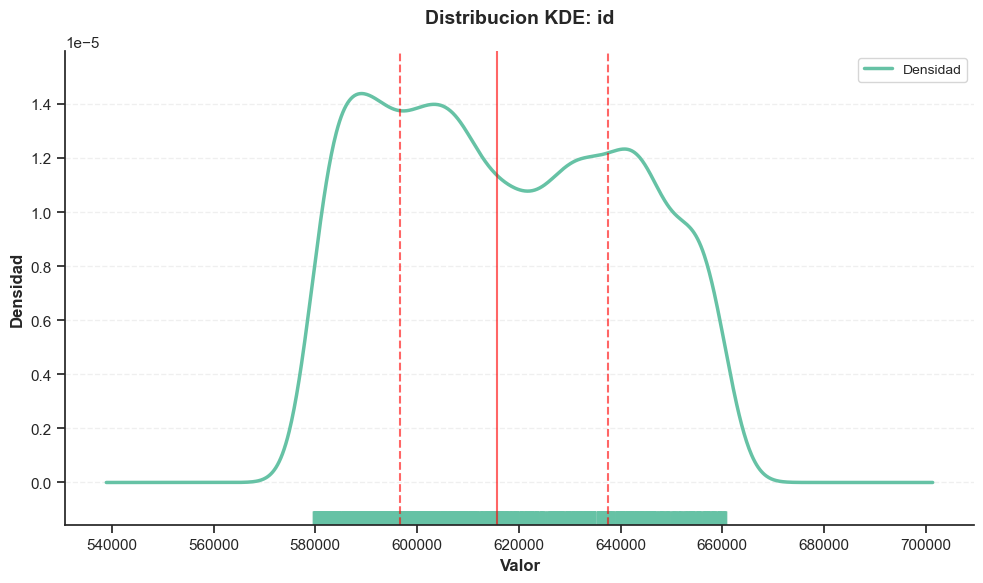

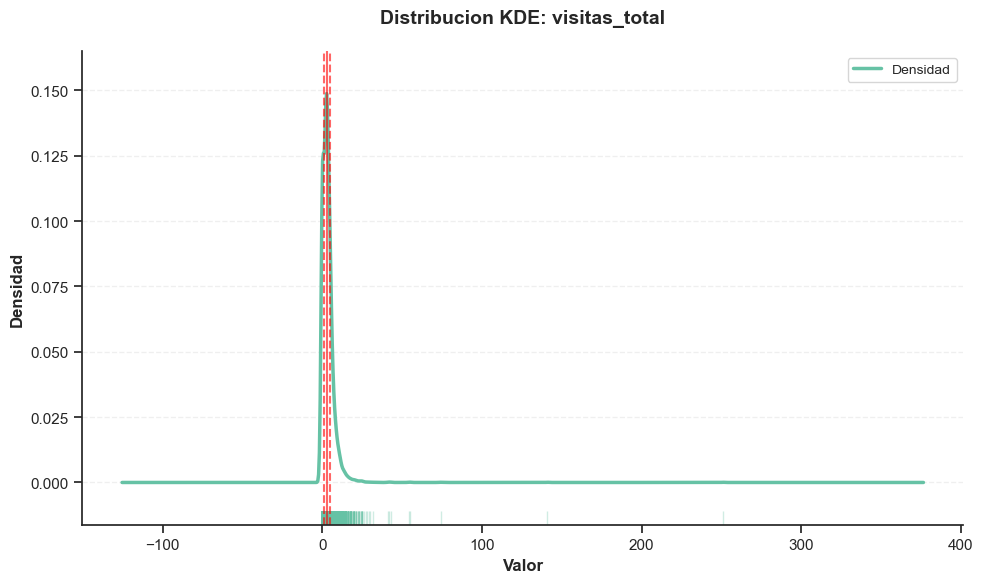

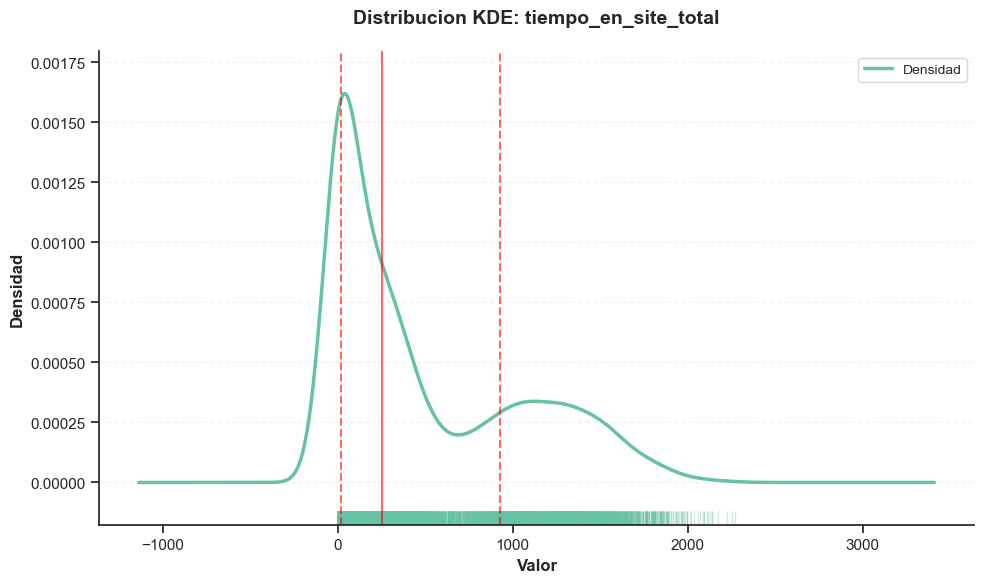

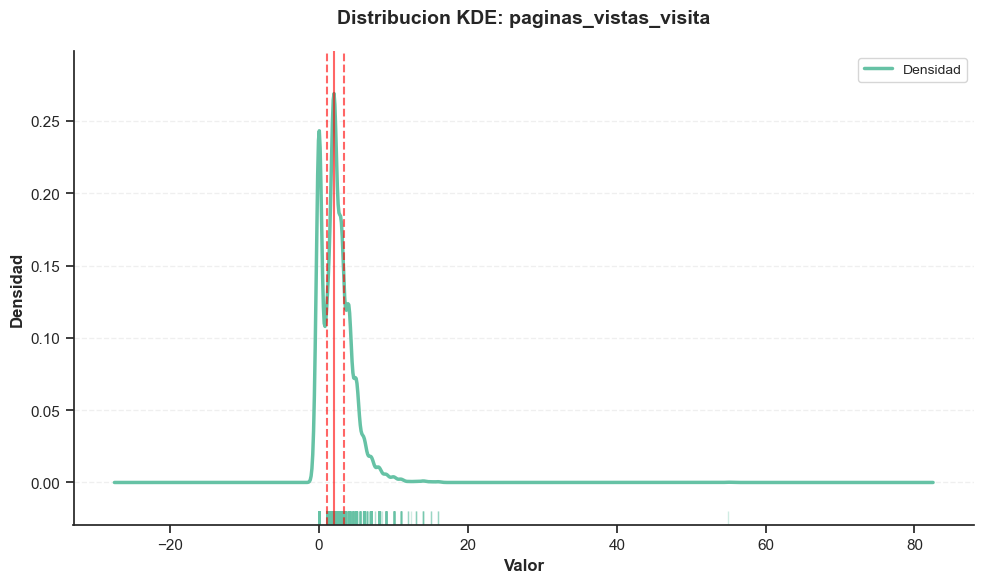

In [55]:
import warnings
warnings.filterwarnings('ignore')

print('='*100)
print('GRAFICOS: VARIABLES NUMERICAS CONTINUAS')
print('='*100)

for col in numeric_continuous:
    fig, ax = plt.subplots(figsize=(10, 6))
    data = df[col].dropna()
    color = sns.color_palette('Set2', 1)[0]
    data.plot(kind='kde', ax=ax, color=color, linewidth=2.5, label='Densidad')
    sns.rugplot(data, ax=ax, color=color, alpha=0.3, height=0.03)
    p25 = data.quantile(0.25)
    p50 = data.quantile(0.50)
    p75 = data.quantile(0.75)
    ax.axvline(p50, color='red', linestyle='-', linewidth=1.5, alpha=0.6)
    ax.axvline(p25, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(p75, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.set_xlabel('Valor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Densidad', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribucion KDE: {col}', fontsize=14, fontweight='bold', pad=20)
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

### Gráficos Especiales: Análisis por Segmento

GRÁFICOS: ANÁLISIS POR SEGMENTO (usuario_nuevo)
⚠️ Advertencia: La columna 'tiempo_sesion' no existe en el DataFrame
⚠️ Advertencia: La columna 'descargas_lm' no existe en el DataFrame


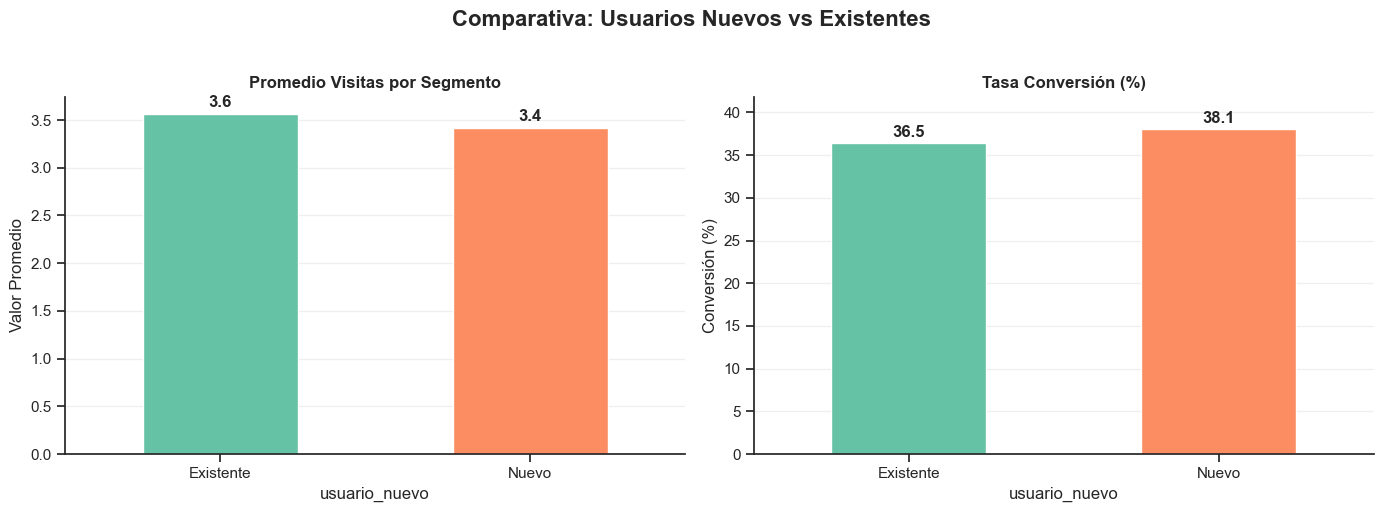

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('='*100)
print('GRÁFICOS: ANÁLISIS POR SEGMENTO (usuario_nuevo)')
print('='*100)

# Verificar que existe la columna usuario_nuevo
if 'usuario_nuevo' not in df.columns:
    raise KeyError("La columna 'usuario_nuevo' no existe en el DataFrame")

# Definir las columnas a graficar (AJUSTA ESTOS NOMBRES A TU CASO)
columnas_analisis = {
    'visitas_total': 'Promedio Visitas por Segmento',
    'tiempo_sesion': 'Tiempo Promedio Sesión',  # CAMBIA este nombre si es diferente
    'descargas_lm': 'Descargas Promedio',
    'compra': 'Tasa Conversión (%)'
}

# Verificar qué columnas existen realmente
columnas_existentes = []
for col in columnas_analisis.keys():
    if col in df.columns:
        columnas_existentes.append(col)
    else:
        print(f"⚠️ Advertencia: La columna '{col}' no existe en el DataFrame")

if len(columnas_existentes) == 0:
    print("❌ Error: No se encontraron columnas válidas para graficar")
    print(f"Columnas disponibles: {df.columns.tolist()}")
else:
    # Crear subplots dinámicamente según las columnas existentes
    n_plots = len(columnas_existentes)
    n_rows = (n_plots + 1) // 2
    n_cols = 2 if n_plots > 1 else 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    fig.suptitle('Comparativa: Usuarios Nuevos vs Existentes', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Aplanar axes si es necesario
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    colors = sns.color_palette('Set2', 2)
    
    for idx, col in enumerate(columnas_existentes):
        ax = axes[idx]
        
        if col == 'compra':
            # Para tasa de conversión
            conversion = df.groupby('usuario_nuevo')['compra'].agg(['sum', 'count'])
            conversion['rate'] = (conversion['sum'] / conversion['count'] * 100)
            conversion['rate'].plot(kind='bar', ax=ax, color=colors)
            ax.set_ylabel('Conversión (%)')
            ax.set_ylim(0, max(conversion['rate']) * 1.1)
        else:
            # Para otras métricas numéricas
            df.groupby('usuario_nuevo')[col].mean().plot(kind='bar', ax=ax, color=colors)
            ax.set_ylabel('Valor Promedio')
        
        ax.set_title(columnas_analisis[col], fontweight='bold')
        ax.set_xticklabels(['Existente', 'Nuevo'], rotation=0)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Agregar valores en las barras
        for i, bar in enumerate(ax.patches):
            height = bar.get_height()
            if not pd.isna(height):
                ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.01),
                       f'{height:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Ocultar subplots no utilizados
    for idx in range(len(columnas_existentes), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

### Gráfico: Correlación con Target

GRAFICO: PODER PREDICTIVO (CORRELACION CON TARGET)


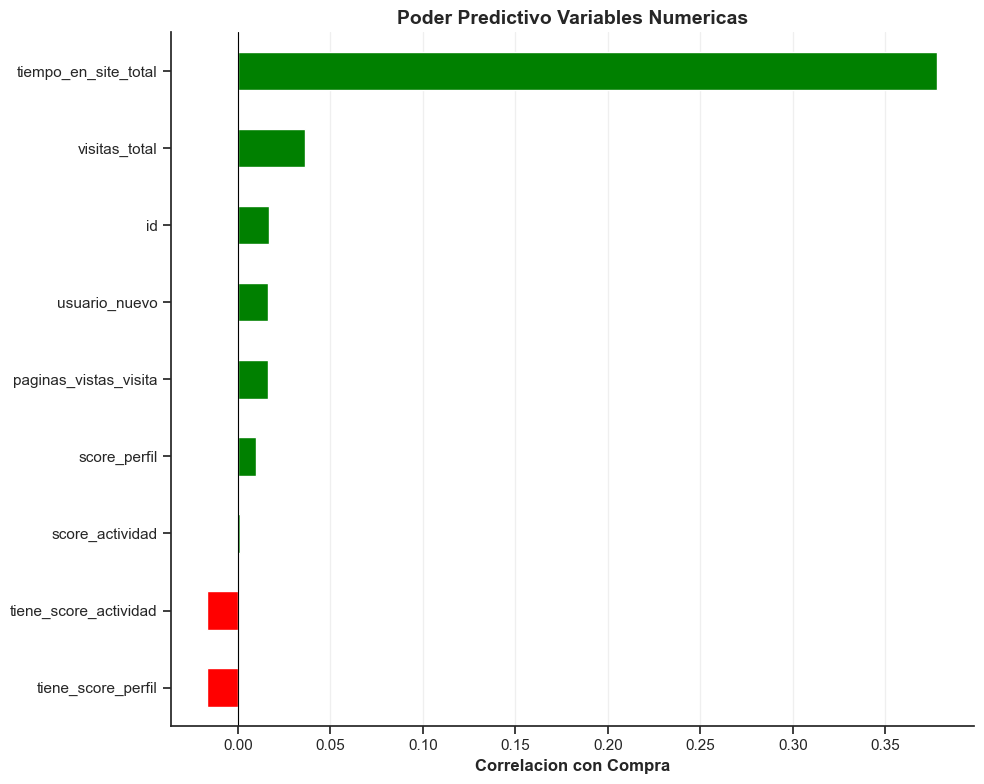

In [57]:
print('='*100)
print('GRAFICO: PODER PREDICTIVO (CORRELACION CON TARGET)')
print('='*100)

all_numeric = numeric_discrete + numeric_continuous
corr_with_target = df[all_numeric].corr()['compra'].drop('compra').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', ax=ax, color=colors)

ax.set_xlabel('Correlacion con Compra', fontsize=12, fontweight='bold')
ax.set_title('Poder Predictivo Variables Numericas', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 📋 TAREA 4: Análisis Estadístico de Variables Categóricas y Booleanas

### Parte 1: Variables Categóricas

In [58]:
print("\n" + "=" * 100)
print("TAREA 4: EDA CATEGÓRICAS Y BOOLEANAS (ANÁLISIS ESTADÍSTICO)")
print("=" * 100)

print("\n" + "=" * 100)
print("PARTE 1: VARIABLES CATEGÓRICAS")
print("=" * 100)

for col in categorical:
    print(f"\n{'─' * 100}")
    print(f"Variable: {col}")
    print(f"{'─' * 100}")

    data = df[col]

    # Información básica
    print(f"Tipo de dato: {data.dtype} | Cardinalidad: {data.nunique()}")

    # Frecuencias
    print(f"\n📊 FRECUENCIAS (todas las categorías):")
    freq_table = data.value_counts()
    freq_df = pd.DataFrame({
        'Categoría': freq_table.index,
        'Frecuencia': freq_table.values,
        '%': (freq_table.values / len(df) * 100).round(2),
        'Acum %': (freq_table.values / len(df) * 100).cumsum().round(2)
    })
    print(freq_df.to_string(index=False))

    # Missing
    missing_count = data.isnull().sum()
    missing_pct = missing_count / len(df) * 100
    print(f"\nMissing: {missing_count} ({missing_pct:.2f}%)")

    # Categoría dominante
    dominant = freq_table.index[0]
    dominant_pct = freq_table.values[0] / len(df) * 100
    print(f"\n👑 CATEGORÍA DOMINANTE:")
    print(f"   {dominant}: {freq_table.values[0]} ({dominant_pct:.2f}%)")

    # Rare labels
    rare_threshold = 1.0
    rare_labels = freq_df[freq_df['%'] < rare_threshold]

    if len(rare_labels) > 0:
        print(f"\n⚠️  CATEGORÍAS RARAS (< {rare_threshold}%):")
        print(rare_labels[['Categoría', '%']].to_string(index=False))
        rare_count = rare_labels['Frecuencia'].sum()
        # ✅ CORREGIDO - Todo en una sola línea
        print(f"   Total de registros en categorías raras: {rare_count} ({rare_count / len(df) * 100:.2f}%)")
    else:
        print(f"\n✅ Sin categorías raras (todas > {rare_threshold}%)")

    # Concentración
    print(f"\n📈 CONCENTRACIÓN:")
    for top_n in [1, 3, 5]:
        top_pct = freq_table.head(top_n).sum() / len(df) * 100
        print(f"   Top-{top_n}: {top_pct:.2f}% de los datos")


TAREA 4: EDA CATEGÓRICAS Y BOOLEANAS (ANÁLISIS ESTADÍSTICO)

PARTE 1: VARIABLES CATEGÓRICAS

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: origen
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: str | Cardinalidad: 4

📊 FRECUENCIAS (todas las categorías):
              Categoría  Frecuencia     %  Acum %
Landing Page Submission        3393 54.04   54.04
                    API        2531 40.31   94.35
          Lead Add Form         331  5.27   99.62
            Lead Import          24  0.38  100.00

Missing: 0 (0.00%)

👑 CATEGORÍA DOMINANTE:
   Landing Page Submission: 3393 (54.04%)

⚠️  CATEGORÍAS RARAS (< 1.0%):
  Categoría    %
Lead Import 0.38
   Total de registros en categorías raras: 24 (0.38%)

📈 CONCENTRACIÓN:
   Top-1: 54.04% de los datos
   Top-3: 99.62% de los datos
   Top-5: 100.00% de los datos

──────────────────────────────────────────────

### Parte 2: Variables Booleanas

In [59]:
print("\n\n" + "=" * 100)
print("PARTE 2: VARIABLES BOOLEANAS")
print("=" * 100)

for col in boolean_cols:
    print(f"\n{'─' * 100}")
    print(f"Variable: {col}")
    print(f"{'─' * 100}")

    data = df[col]

    # Información básica
    print(f"Tipo de dato: {data.dtype} | Valores únicos: {data.nunique()}")
    print(f"Valores posibles: {sorted(data.unique())}")

    # Frecuencias
    print(f"\n📊 FRECUENCIAS:")
    freq_table = data.value_counts().sort_index()
    freq_df = pd.DataFrame({
        'Valor': freq_table.index,
        'Frecuencia': freq_table.values,
        '%': (freq_table.values / len(df) * 100).round(2)
    })
    print(freq_df.to_string(index=False))

    # Missing
    missing_count = data.isnull().sum()
    missing_pct = missing_count / len(df) * 100
    print(f"\nMissing: {missing_count} ({missing_pct:.2f}%)")

    # Categoría dominante
    dominant = freq_table.index[0]
    dominant_pct = freq_table.values[0] / len(df) * 100
    print(f"\n👑 VALOR DOMINANTE:")
    print(f"   {dominant}: {freq_table.values[0]} ({dominant_pct:.2f}%)")

    # Desbalance
    if len(freq_table) == 2:
        ratio = freq_table.values[1] / freq_table.values[0]
        print(f"\n⚖️  BALANCE:")
        # ✅ CORREGIDO - Todo en una sola línea
        print(f"   Ratio: {ratio:.4f} ({freq_table.values[1] / len(df) * 100:.2f}% vs {freq_table.values[0] / len(df) * 100:.2f}%)")
        if ratio < 0.05 or ratio > 20:
            print(f"   ⚠️  Variable muy desbalanceada (una categoría >> otra)")




PARTE 2: VARIABLES BOOLEANAS

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: no_enviar_email
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: str | Valores únicos: 2
Valores posibles: ['No', 'Yes']

📊 FRECUENCIAS:
Valor  Frecuencia     %
   No        5792 92.24
  Yes         487  7.76

Missing: 0 (0.00%)

👑 VALOR DOMINANTE:
   No: 5792 (92.24%)

⚖️  BALANCE:
   Ratio: 0.0841 (7.76% vs 92.24%)

────────────────────────────────────────────────────────────────────────────────────────────────────
Variable: descarga_lm
────────────────────────────────────────────────────────────────────────────────────────────────────
Tipo de dato: str | Valores únicos: 2
Valores posibles: ['No', 'Yes']

📊 FRECUENCIAS:
Valor  Frecuencia     %
   No        4291 68.34
  Yes        1988 31.66

Missing: 0 (0.00%)

👑 VALOR DOMINANTE:
   No: 4291 (68.34%)

⚖️  BALANCE:
   Ratio: 0.46

### Parte 3: Análisis de Asociación con Target

In [60]:
print("\n\n" + "=" * 100)
print("ANÁLISIS: RELACIÓN CON TARGET (compra)")
print("=" * 100)

all_cat = categorical + boolean_cols

# Calcular cramér's v


def cramers_v(x, y):
    """Calcular Cramér's V statistic para asociación entre dos variables categóricas"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ((confusion_matrix -
             confusion_matrix.sum(axis=0) *
             confusion_matrix.sum(axis=1) /
             confusion_matrix.sum().sum()) ** 2 /
            (confusion_matrix.sum(axis=0) *
             confusion_matrix.sum(axis=1) /
             confusion_matrix.sum().sum())).sum().sum()

    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0


print("\n🔗 CRAMÉR'S V (Asociación con target):")
cramers_values = []
for col in all_cat:
    cv = cramers_v(df[col], df['compra'])
    cramers_values.append((col, cv))

cramers_values.sort(key=lambda x: x[1], reverse=True)
for col, cv in cramers_values:
    print(f"   {col:30s}: {cv:.4f}")

# Tasas de conversión por categoría
print("\n\n📊 TASAS DE CONVERSIÓN POR CATEGORÍA:")

for col in ['origen', 'fuente', 'ambito', 'ocupacion']:
    print(f"\n{col.upper()}:")
    conv_by_cat = df.groupby(col).agg({
        'compra': ['sum', 'count']
    }).round(2)
    conv_by_cat.columns = ['Compras', 'Total']
    conv_by_cat['Tasa %'] = (
        conv_by_cat['Compras'] /
        conv_by_cat['Total'] *
        100).round(2)
    conv_by_cat = conv_by_cat.sort_values('Tasa %', ascending=False)
    print(conv_by_cat)




ANÁLISIS: RELACIÓN CON TARGET (compra)

🔗 CRAMÉR'S V (Asociación con target):
   origen                        : 0.0000
   fuente                        : 0.0000
   ult_actividad                 : 0.0000
   ambito                        : 0.0000
   ocupacion                     : 0.0000
   no_enviar_email               : 0.0000
   descarga_lm                   : 0.0000


📊 TASAS DE CONVERSIÓN POR CATEGORÍA:

ORIGEN:
                         Compras  Total  Tasa %
origen                                         
Lead Add Form                308    331   93.05
Lead Import                    9     24   37.50
Landing Page Submission     1234   3393   36.37
API                          784   2531   30.98

FUENTE:
                Compras  Total  Tasa %
fuente                                
Otros               338    461   73.32
Google              798   2006   39.78
Organic Search      312    809   38.57
Direct Traffic      579   1784   32.46
Chat                308   1219   25.27

AMBITO:

### Parte 4: Análisis de Coocurrencia (Booleanas)

## 📈 TAREA 5: Análisis Gráfico de Variables Categóricas y Booleanas

### Gráficos: Variables Categóricas


TAREA 5: EDA CATEGÓRICAS Y BOOLEANAS (ANÁLISIS GRÁFICO)

GRÁFICOS: VARIABLES CATEGÓRICAS


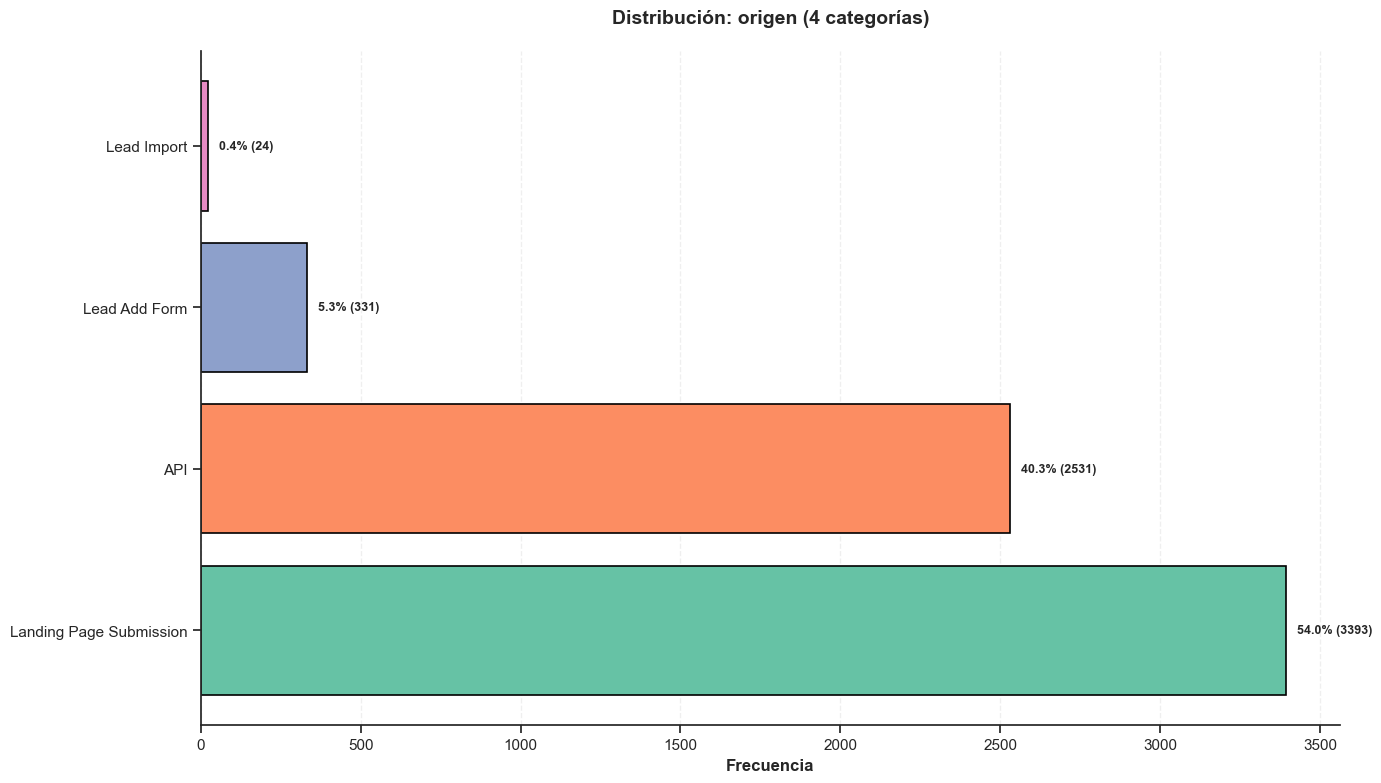

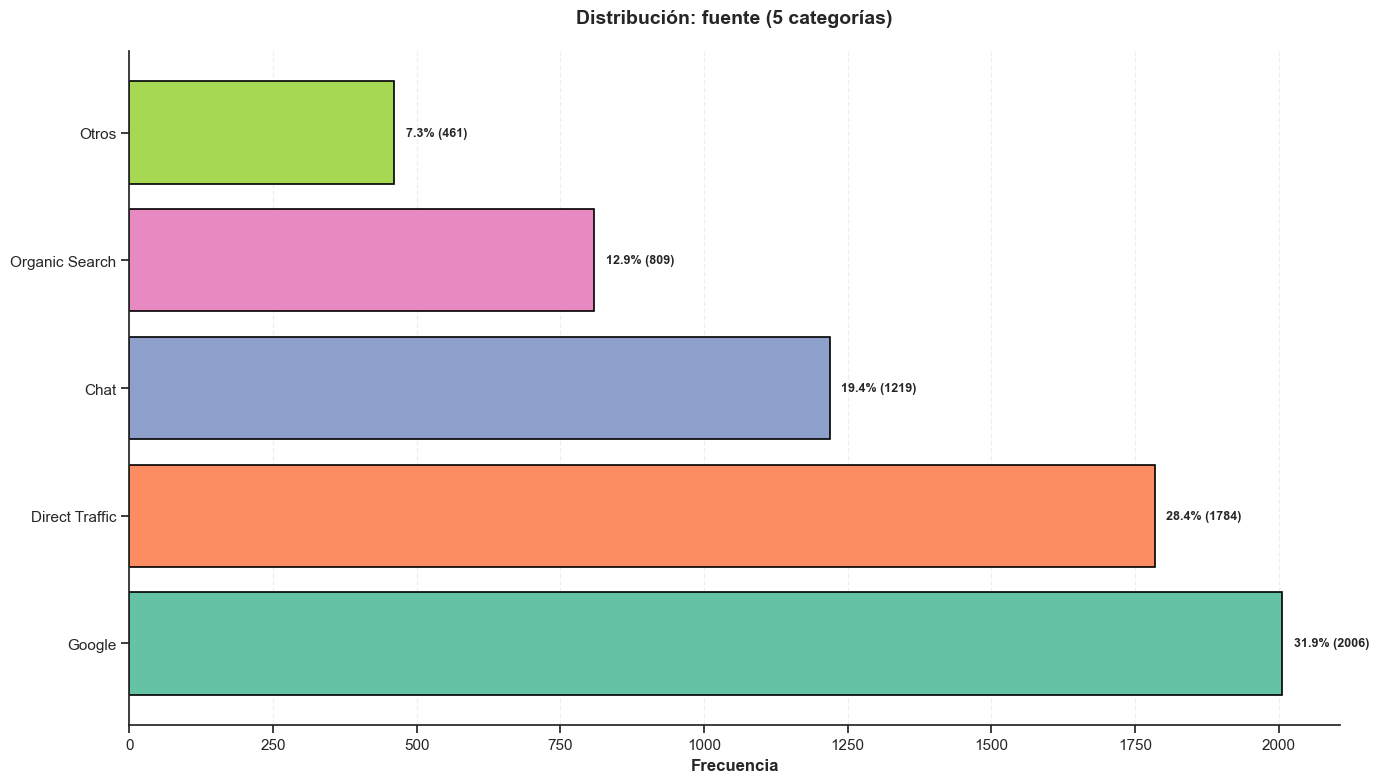

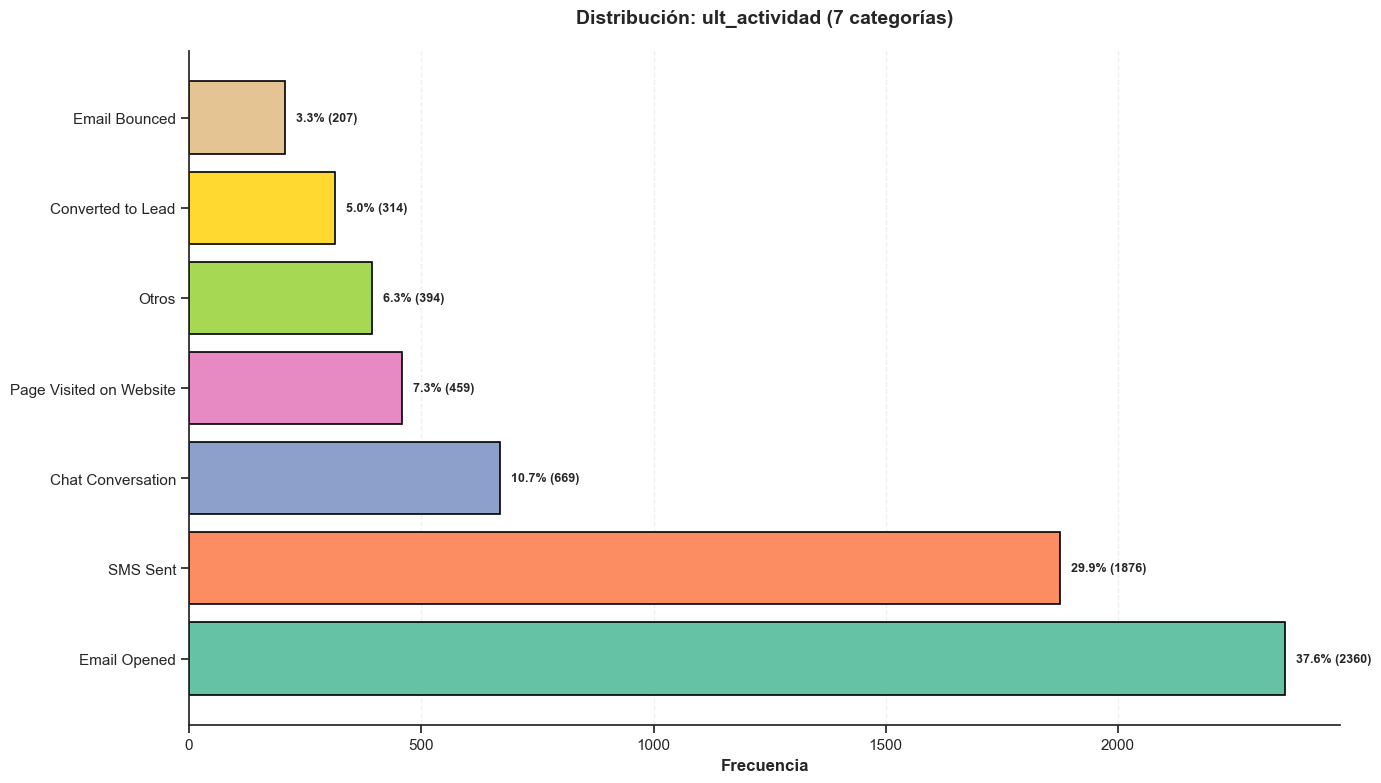

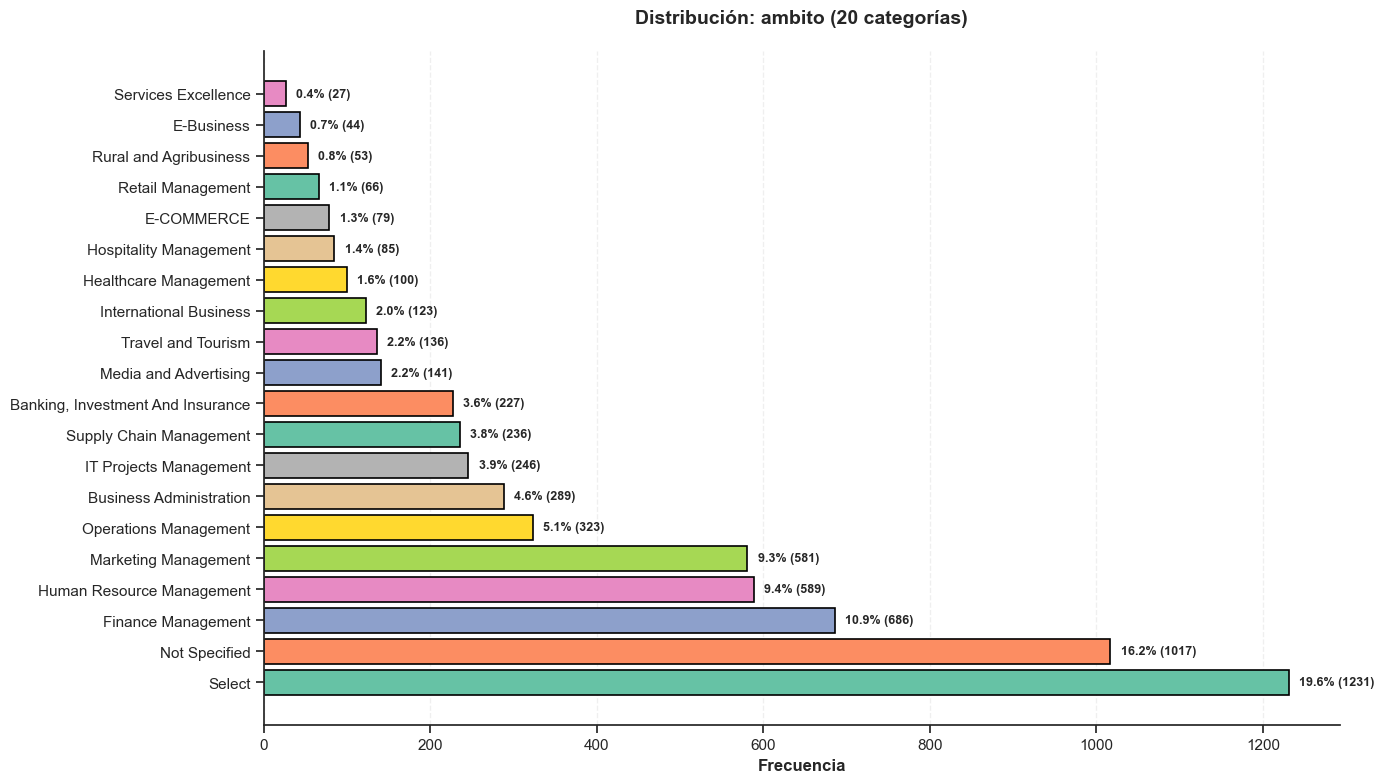

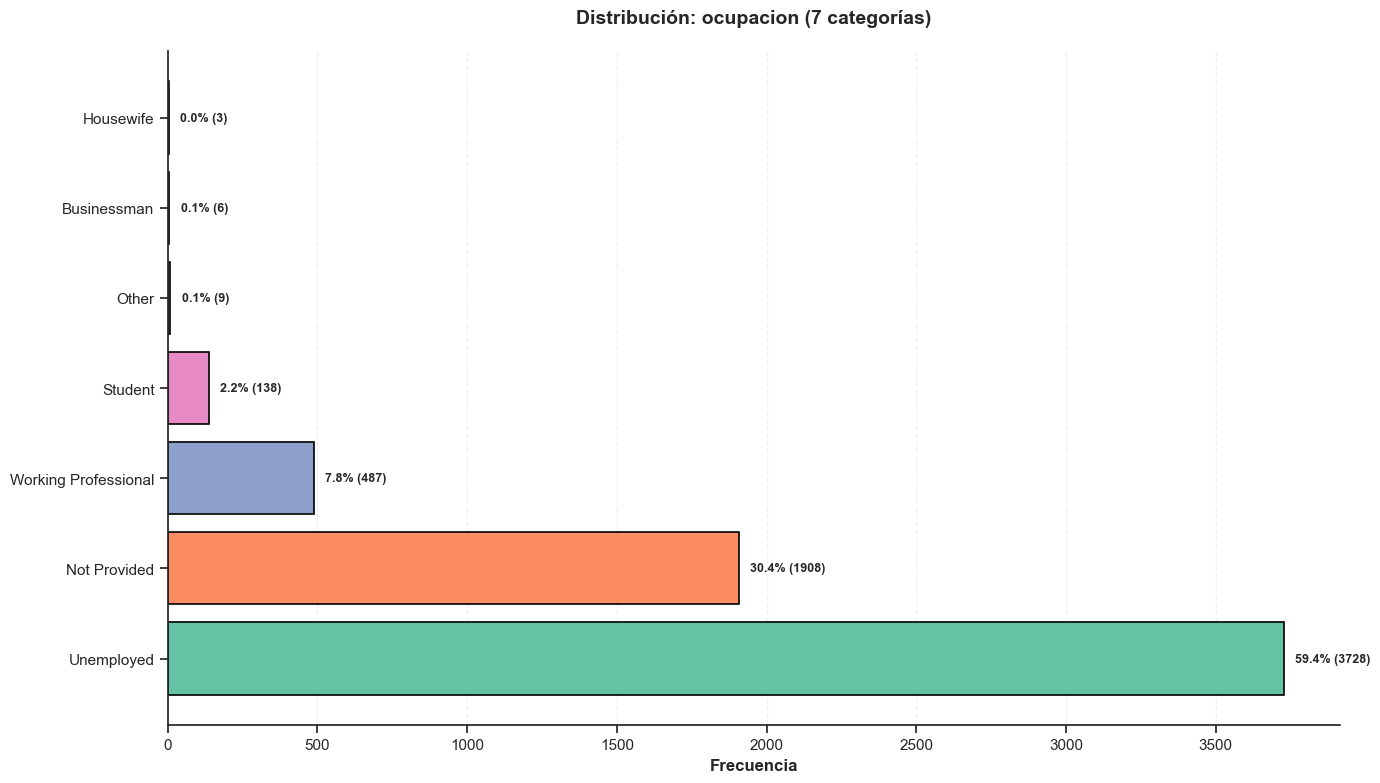

In [61]:
print("\n" + "=" * 100)
print("TAREA 5: EDA CATEGÓRICAS Y BOOLEANAS (ANÁLISIS GRÁFICO)")
print("=" * 100)
print("\n" + "=" * 100)
print("GRÁFICOS: VARIABLES CATEGÓRICAS")
print("=" * 100)

for col in categorical:
    fig, ax = plt.subplots(figsize=(14, 8))
    counts = df[col].value_counts()
    colors = sns.color_palette("Set2", len(counts))
    
    bars = ax.barh(range(len(counts)), counts.values, color=colors, edgecolor="black", linewidth=1.2)
    
    for i, (idx, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        ax.text(count + max(counts) * 0.01, i, f"{pct:.1f}% ({int(count)})",
                va="center", ha="left", fontweight="bold", fontsize=9)
    
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=11)
    ax.set_xlabel("Frecuencia", fontsize=12, fontweight="bold")
    ax.set_title(f"Distribución: {col} ({len(counts)} categorías)", fontsize=14, fontweight="bold", pad=20)
    
    ax.xaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

### Gráficos: Variables Booleanas


GRÁFICOS: VARIABLES BOOLEANAS


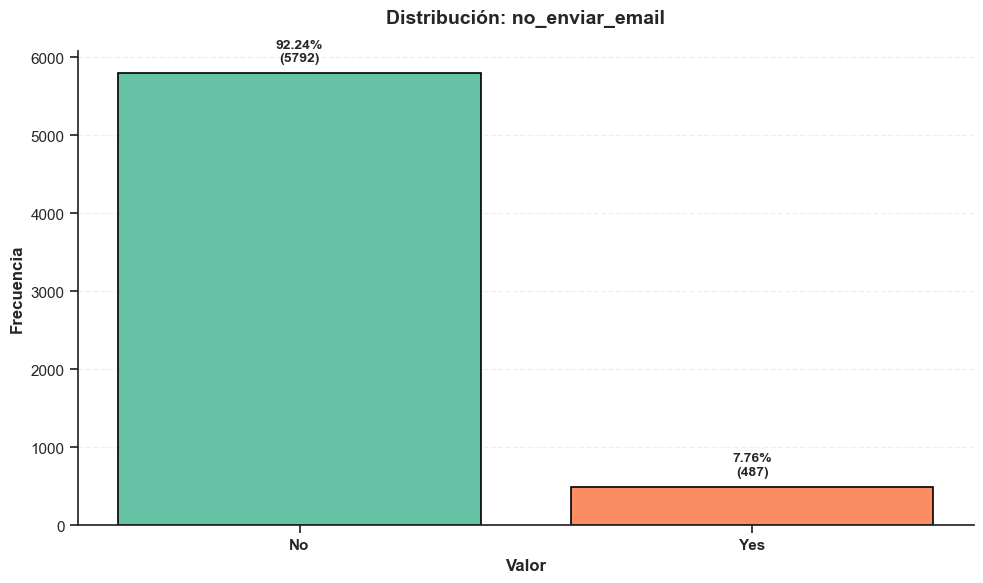

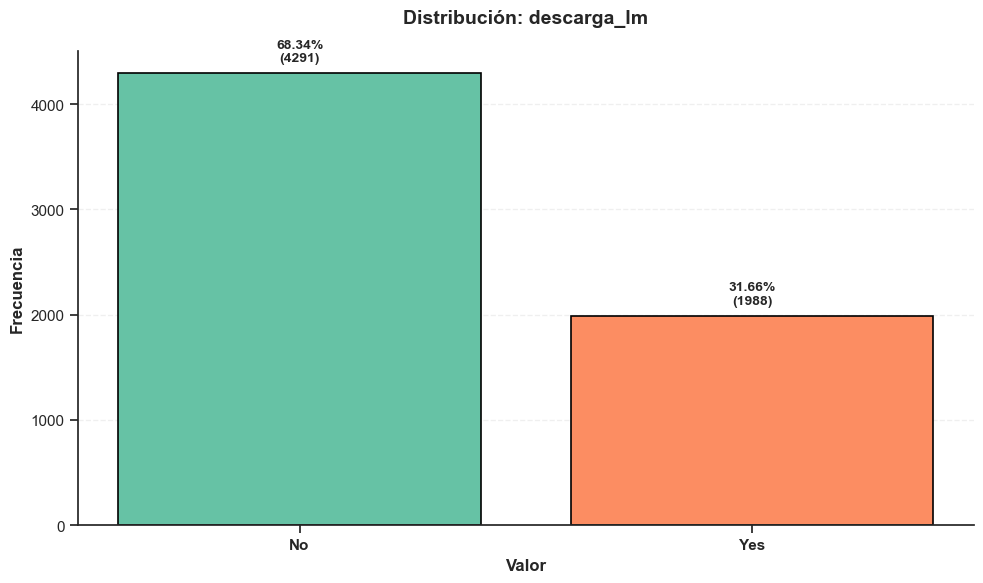

In [62]:
print("\n" + "=" * 100)
print("GRÁFICOS: VARIABLES BOOLEANAS")
print("=" * 100)

for col in boolean_cols:
    fig, ax = plt.subplots(figsize=(10, 6))
    counts = df[col].value_counts().sort_index()
    colors = sns.color_palette("Set2", len(counts))
    
    bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='black', linewidth=1.2)
    
    for i, (idx, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        ax.text(i, count + max(counts) * 0.02, f'{pct:.2f}%\n({int(count)})',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribución: {col}', fontsize=14, fontweight='bold', pad=20)
    
    ax.yaxis.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

### Gráficos: Tasas de Conversión por Categoría

GRAFICOS: TASAS DE CONVERSION POR CATEGORIA


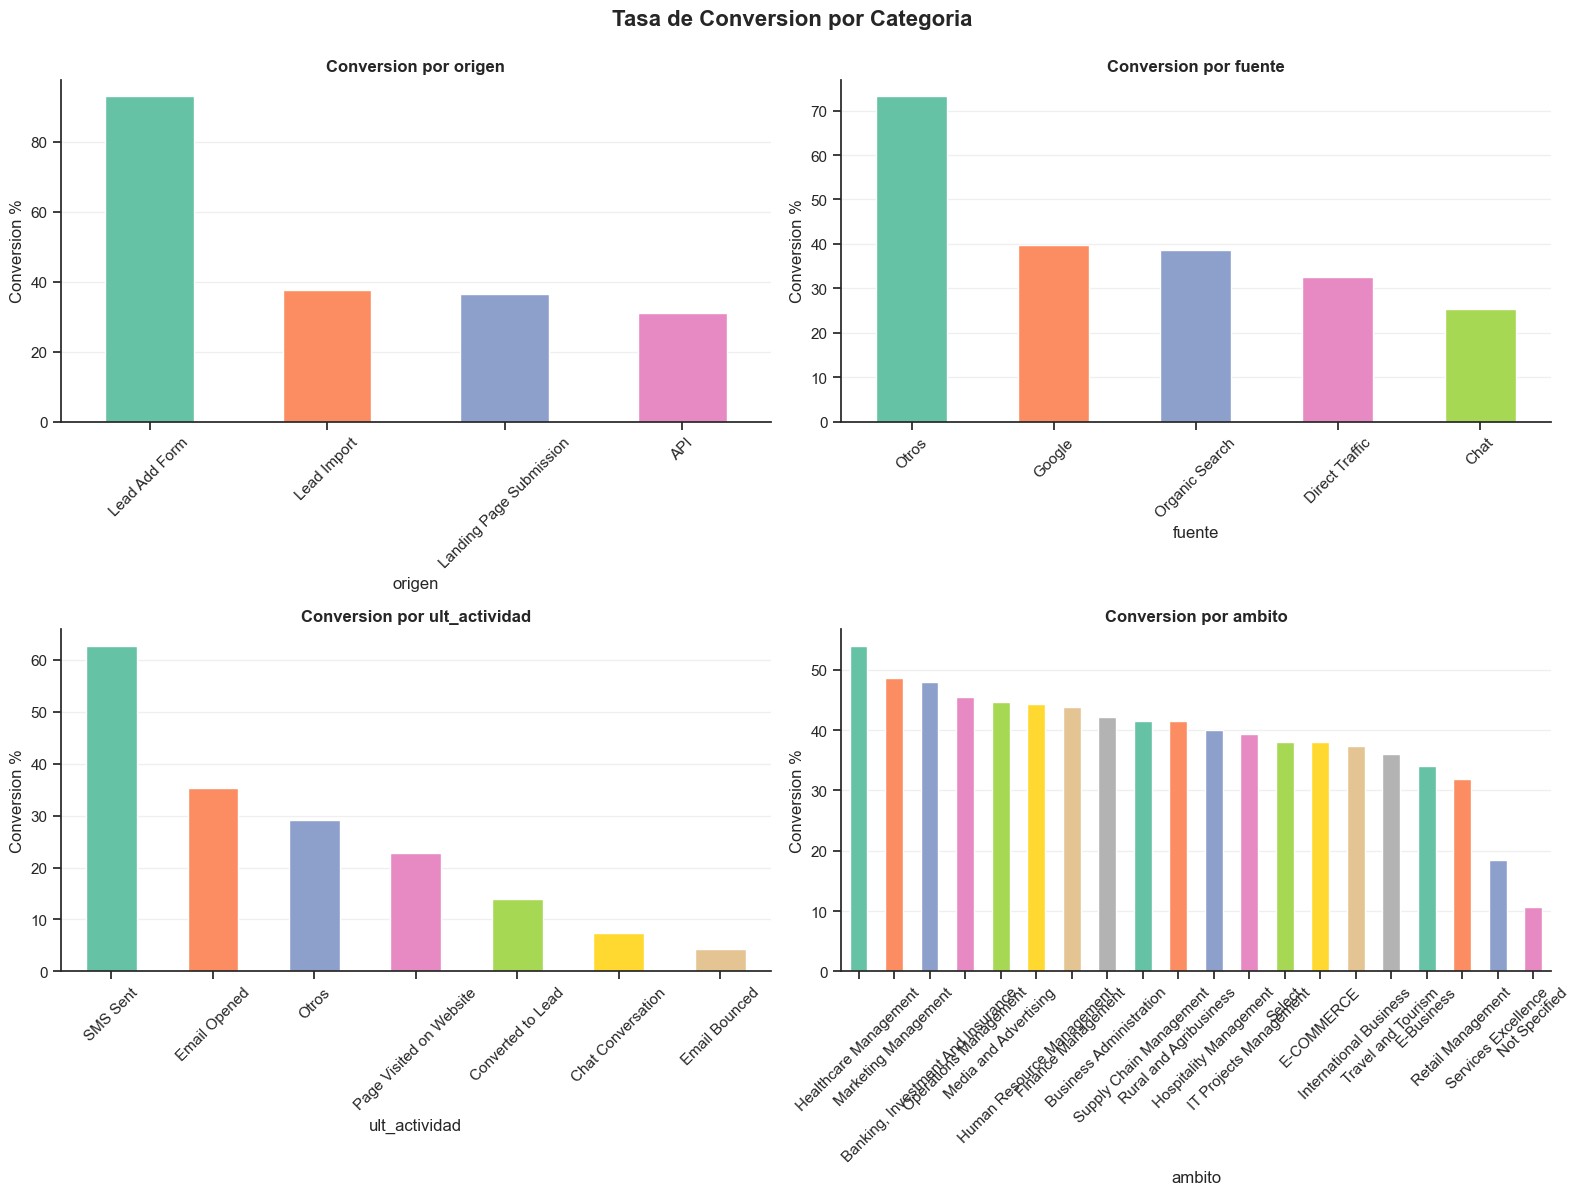

In [63]:
print('='*100)
print('GRAFICOS: TASAS DE CONVERSION POR CATEGORIA')
print('='*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tasa de Conversion por Categoria', fontsize=16, fontweight='bold', y=0.995)

cat_to_plot = categorical[:4] if len(categorical) >= 4 else categorical

for idx, col in enumerate(cat_to_plot):
    ax = axes[idx // 2, idx % 2]
    conversion = df.groupby(col)['compra'].agg(['sum', 'count'])
    conversion['rate'] = (conversion['sum'] / conversion['count'] * 100)
    conversion['rate'].sort_values(ascending=False).plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(conversion)))
    ax.set_title(f'Conversion por {col}', fontweight='bold')
    ax.set_ylabel('Conversion %')
    ax.set_xlabel(col)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Gráfico: Heatmap de Interacción


GRÁFICO: INTERACCIÓN origen × descarga_lm


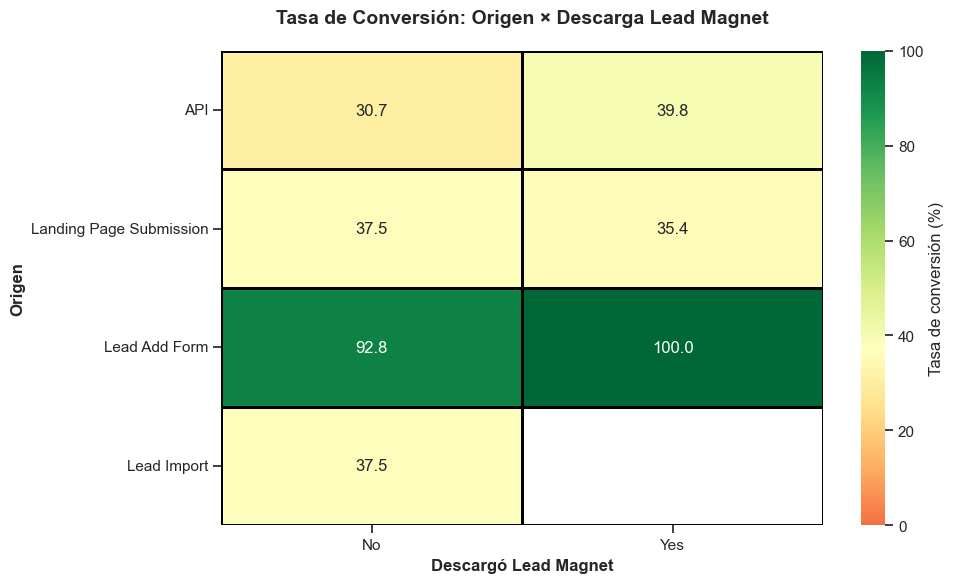


✅ TAREA 5 COMPLETADA - GRÁFICOS DE CATEGÓRICAS GENERADOS


In [64]:
print("\n" + "=" * 100)
print("GRÁFICO: INTERACCIÓN origen × descarga_lm")
print("=" * 100)

fig, ax = plt.subplots(figsize=(10, 6))
crosstab = pd.crosstab(df['origen'], df['descarga_lm'], values=df['compra'], aggfunc='mean') * 100

sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='RdYlGn', center=37,
            cbar_kws={'label': 'Tasa de conversión (%)'}, ax=ax,
            vmin=0, vmax=100, linewidths=1, linecolor='black')

ax.set_title('Tasa de Conversión: Origen × Descarga Lead Magnet',
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Descargó Lead Magnet', fontsize=12, fontweight='bold')
ax.set_ylabel('Origen', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("✅ TAREA 5 COMPLETADA - GRÁFICOS DE CATEGÓRICAS GENERADOS")
print("=" * 100)

## 📌 Resumen Final del EDA

In [65]:
print("\n" + "=" * 100)
print("✅ EDA COMPLETA - RESUMEN FINAL")
print("=" * 100)
print(f"""
📊 DATASET:
   • Registros: {df.shape[0]}
   • Variables: {df.shape[1]}
   • Target (compra): {df['compra'].sum()} positivos (~37%)

📈 VARIABLES ANALIZADAS:
   • Numéricas discretas: {len(numeric_discrete)}
   • Numéricas continuas: {len(numeric_continuous)}
   • Categóricas: {len(categorical)}
   • Booleanas: {len(boolean_cols)}

📁 GRÁFICOS GENERADOS:
   • 01_discreto_*.png (6 gráficos) - Variables discretas
   • 02_continuo_*.png (4 gráficos) - Variables continuas (KDE)
   • 03_comparativa_usuario_nuevo.png - Segmentación por usuario
   • 04_correlacion_target.png - Poder predictivo
   • 05_categorica_*.png (5 gráficos) - Variables categóricas
   • 06_booleana_*.png (6 gráficos) - Variables booleanas
   • 07_conversion_por_categoria.png - Tasas de conversión
   • 08_interaccion_origen_descarga.png - Heatmap de interacción

   📊 TOTAL: 31 gráficos de alta calidad

📋 ARCHIVOS GENERADOS:
   • 06_resultados/clasificacion_variables.json - Clasificación de variables
   • 06_resultados/ - Resultados del análisis

🎯 PRÓXIMOS PASOS:
   • Ingeniería de features
   • Modelado predictivo
   • Evaluación y tuning
""")

print("=" * 100)
print("✅ FIN DEL ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 100)



✅ EDA COMPLETA - RESUMEN FINAL

📊 DATASET:
   • Registros: 6279
   • Variables: 17
   • Target (compra): 2335 positivos (~37%)

📈 VARIABLES ANALIZADAS:
   • Numéricas discretas: 6
   • Numéricas continuas: 4
   • Categóricas: 5
   • Booleanas: 2

📁 GRÁFICOS GENERADOS:
   • 01_discreto_*.png (6 gráficos) - Variables discretas
   • 02_continuo_*.png (4 gráficos) - Variables continuas (KDE)
   • 03_comparativa_usuario_nuevo.png - Segmentación por usuario
   • 04_correlacion_target.png - Poder predictivo
   • 05_categorica_*.png (5 gráficos) - Variables categóricas
   • 06_booleana_*.png (6 gráficos) - Variables booleanas
   • 07_conversion_por_categoria.png - Tasas de conversión
   • 08_interaccion_origen_descarga.png - Heatmap de interacción

   📊 TOTAL: 31 gráficos de alta calidad

📋 ARCHIVOS GENERADOS:
   • 06_resultados/clasificacion_variables.json - Clasificación de variables
   • 06_resultados/ - Resultados del análisis

🎯 PRÓXIMOS PASOS:
   • Ingeniería de features
   • Modelado p

In [66]:
df.head()

,id,origen,fuente,no_enviar_email,compra,visitas_total,tiempo_en_site_total,paginas_vistas_visita,ult_actividad,ambito,ocupacion,score_actividad,score_perfil,descarga_lm,tiene_score_actividad,tiene_score_perfil,usuario_nuevo
1242,646181,API,Google,No,0,2.0,200,2.0,Email Opened,Select,Unemployed,13.0,15.0,No,1,1,0
8583,582361,Landing Page Submission,Direct Traffic,No,0,4.0,373,4.0,Otros,Human Resource Management,Unemployed,13.0,20.0,Yes,1,1,0
5308,607963,Landing Page Submission,Direct Traffic,No,0,2.0,1122,2.0,Email Opened,IT Projects Management,Not Provided,0.0,0.0,Yes,0,0,1
8030,586622,API,Chat,No,0,0.0,0,0.0,Chat Conversation,Not Specified,Not Provided,17.0,15.0,No,1,1,0
2287,636823,Lead Add Form,Otros,No,1,0.0,0,0.0,SMS Sent,Marketing Management,Unemployed,15.0,20.0,No,1,1,0
